# Identifying Obstacles to Equitable Flood Mitigation Funding

Julian Plough (University of North Carolina)  
Miyuki Hino [](https://orcid.org/0000-0001-9369-5769) (University of North Carolina at Chapel Hill, University of North Carolina)  
Antonia Sebastian [](https://orcid.org/0000-0002-4309-2561) (University of North Carolina at Chapel Hill, University of North Carolina)  
Helena Garcia [](https://orcid.org/0009-0008-3189-1658) (University of North Carolina)  
Russell Blessing [](https://orcid.org/0000-0003-4973-4032) (University of North Carolina at Chapel Hill)  
June 2, 2026

As damages from floods, fires, and other climate extremes mount, public investments in risk reduction have also grown. In the US, FEMA made over \$1.6 billion available through its two main competitive pre-disaster mitigation programs — Building Resilient Infrastructure and Communities (BRIC) and Flood Mitigation Assistance (FMA) — for FY2024, and demand for such funds regularly exceeds available funding. Evidence suggests that in this competitive landscape for funding, urban and whiter communities have fared better at obtaining funding but are often spending it on more disadvantaged neighborhoods within them. However, the reasons for this trend are unclear: complexities in the application process, cost-benefit analysis requirements, and flood damage may all play a role in driving the uneven funding patterns. Here, using a novel dataset tracking properties from flood exposure to application to funding receipt, we identify how each hurdle in the mitigation process shapes the properties that ultimately benefit. Our results demonstrate that the application stage is the critical pinch point in the mitigation funding pipeline: of all flooded properties, 67.5% are eligible for public assistance and 61% are located in communities where local governments have submitted applications, yet only 2.3% apply and approximately 1% are ultimately funded. Homeowners in less-white neighborhoods and more affordable homes relative to their neighbors are more likely to apply, and this trend deepens for those who ultimately receive funding, while higher flood exposure has minimal correlation — implying that funding may not reach all who need it or may be interested.

In [ ]:
library(readr)
library(dplyr)


Attaching package: 'dplyr'

The following objects are masked from 'package:stats':

    filter, lag

The following objects are masked from 'package:base':

    intersect, setdiff, setequal, union

# Introduction

Flooding is the most costly natural hazard in the United States, and projected climate changes will intensify both its frequency and its financial burden \[@noaanationalcentersforenvironmentalinformationUSBillionDollarWeather2024\]. An estimated 41 million people live within the 100-year floodplain, more than twice the figure suggested by FEMA’s official flood maps, and the populations most exposed are disproportionately low-income, Black, and Native American \[@tateFloodExposureSocial2021\]. In response to mounting losses, federal investment in flood risk reduction has grown substantially, averaging over \$1.2 billion per year in FEMA hazard mitigation grants alone over the last decade. Yet growing evidence suggests this investment is not reaching those who need it most. Nationwide analyses find that wealthier and whiter counties have secured more federal mitigation funding, while racially and economically marginalized communities, which bear a disproportionate flood burden, have received comparatively less \[@machManagedRetreatVoluntary2019; @elliottRacialInequitiesFederal2020a; @loughranUnequalRetreatsHow2022\]. Several mechanisms have been proposed to explain this pattern: federal cost-benefit analysis requirements that systematically favor high-value properties, limited local government capacity to administer grants, and lack of household awareness about available funding. Prior research, however, has been constrained by a fundamental data limitation: we can observe only who *receives* funding, not who is eligible or who applies. As a result, it remains unclear where in the process inequities first emerge and which interventions would most effectively improve access.

Here, we combine novel datasets spanning over two decades of flood exposure, grant applications, and funding allocations in North Carolina to examine the full flooded-to-funded pipeline (Fig. 1). Flood exposure is derived from a random forest model trained on address-level National Flood Insurance Program (NFIP) records, producing inundation footprints for 78 damaging events between 1996 and 2020 \[@garciaReconstructingRepetitiveFlood2025\]. We link these exposure records to property-level application and funding data for FEMA Hazard Mitigation Assistance (HMA), provided by the North Carolina Department of Public Safety. Together, these datasets allow us to track individual properties across five stages (flooded, eligible, in an applying community, applied, and funded) and to examine how the composition of properties shifts in terms of flood exposure history, property value, and neighborhood racial demographics at each transition. This is the first analysis to follow properties from flood exposure through to mitigation funding outcome at the property level, making it possible to distinguish between households that are not being selected and those that never enter the applicant pool at all.

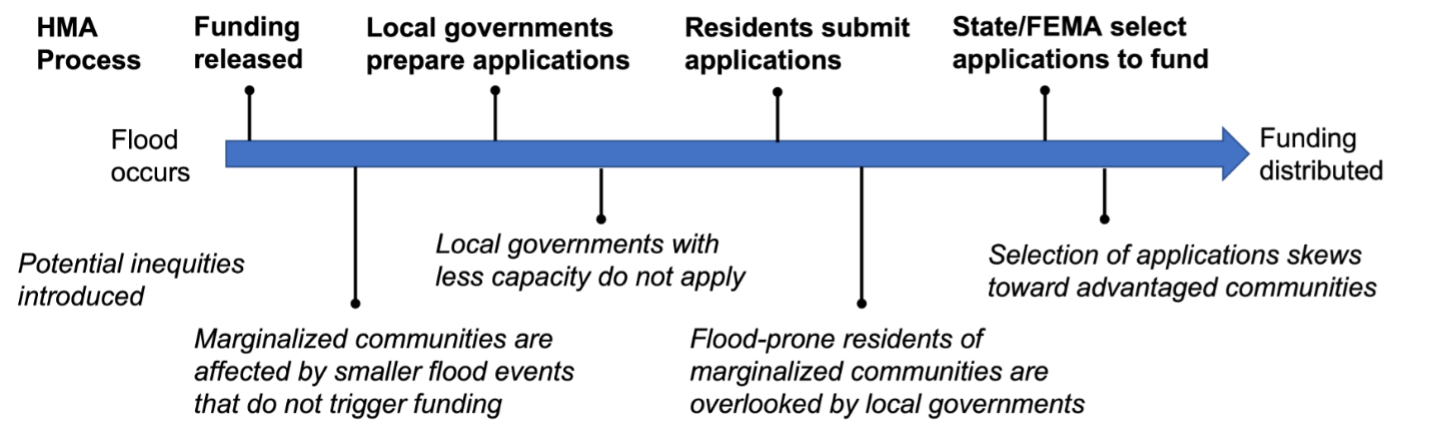{#fig-funding-pipeline }

## Access to federal funding for climate resilience

The federal government is the primary backstop against flood losses in the United States, operating programs spanning pre-event risk reduction, immediate post-disaster relief, and longer-term recovery. We focus our analysis on the Federal Emergency Management Agency (FEMA), which leads disaster response and administers the nation’s largest risk mitigation programs, though other federal entities including the US Army Corps of Engineers, the National Oceanic and Atmospheric Administration, and the Environmental Protection Agency also play important roles.

Concerns about equitable access to FEMA assistance have been documented in the immediate aftermath of disasters for decades. Following presidential disaster declarations, FEMA’s Individuals and Households Program (IHP) provides up to approximately \$44,000 per household for temporary housing, property repair, unemployment assistance, and other immediate needs. Racial and income disparities in IHP access have been observed across a wide range of events, including the 1994 Northridge earthquake \[@bolinNorthridgeEarthquakeCommunitybased1998\], Hurricane Katrina \[@kamelSocialMarginalisationFederal2012\], Hurricane Dolly in South Texas \[@riveraProceduralVulnerabilityIts2022\], and the 2017 Thomas Fire \[@mendezInvisibleVictimsDisaster2020\]. More broadly, studies find that social vulnerability is inversely associated with access to federal disaster recovery funds even after accounting for the extent of damage \[@emrichAssessingDistributiveInequities2022; @drakesSocialVulnerabilityShortTerm2021; @wilsonFloodRecoveryOutcomes2021; @bentoRaciallyUnequalImpacts2022\]. Across disaster types and geographies, the pattern is consistent: federal assistance systematically underserves the communities most exposed to hazard \[@rakerStratifyingDisasterState2023\].

Similar concerns have emerged around FEMA’s risk mitigation programs, which fund long-term adaptation rather than immediate recovery. Typical Hazard Mitigation Assistance (HMA) projects include home elevations, property buyouts, and community-scale infrastructure; since 2020, the Building Resilient Infrastructure and Communities (BRIC) program has expanded community-wide project funding. Among property-scale programs, buyouts have received the most scrutiny. In a buyout, homeowners sell flood-prone properties to local governments, which demolish structures and restore the land to open space. Initiated in 1985 and now totaling over 43,000 completed transactions nationally, the buyout program has shifted from its rural origins into an increasingly urban policy \[@machManagedRetreatVoluntary2019\]. Its geographic distribution is deeply uneven: states with the highest cumulative flood damages (Florida, Louisiana, Mississippi) rank among the lowest for buyout deployment, while activity concentrates in wealthier, denser counties with greater administrative capacity \[@machManagedRetreatVoluntary2019\]. Within those counties, bought-out properties are concentrated in lower-income and more racially diverse neighborhoods, a pattern Mach et al. \[-@machManagedRetreatVoluntary2019\] describe as a “buyout paradox” in which government capacity governs access at the county scale while within-county selection follows a different logic \[@elliottRacialInequitiesFederal2020a; @loughranUnequalRetreatsHow2022\]. Home elevation funding exhibits a different and more troubling pattern, flowing disproportionately toward high-income and predominantly white communities \[@frankFEMAHomeElevation2022\].

A structural driver of these disparities is the federal cost-benefit analysis (CBA) requirement. Because CBA estimates avoided losses as a function of property replacement value, projects in lower-income neighborhoods systematically generate lower benefit-to-cost ratios, making them less competitive for funding even when flood exposure is severe \[@tateFloodExposureSocial2021; @junodEquitableInvestmentsResilience2021a; @millerCostCostEffectivenessExpanding2023\]. The result is an equity trap in which the households most exposed and most vulnerable are simultaneously least likely to clear the threshold that determines who gets funded.

## Procedural challenges to accessing funding

While these structural barriers shape outcomes at a broad scale, the mechanisms that produce inequity operate at the level of specific program rules and local implementation practices. The HMA application process is lengthy and multi-layered. After a presidential disaster declaration releases funding, state and local governments identify eligible properties, assist homeowners in compiling required documentation (including cost-benefit analyses, insurance records, and title documentation), and submit project proposals. Local governments (“sub-applicants”) forward proposals to the state (“applicant”), which screens projects before submitting to FEMA for final review. The full process from disaster declaration to project closeout averages nearly six years \[@machManagedRetreatVoluntary2019\]. The federal government covers 75% of project costs; North Carolina covers the remaining 25% non-federal match, reducing a significant barrier that cash-strapped local governments face in other states.

Inequities can arise at every stage. At the county level, administrative capacity is the primary bottleneck: governments with dedicated staff, prior grant experience, and stronger institutional networks are far more effective at developing and submitting competitive proposals \[@machManagedRetreatVoluntary2019; @junodEquitableInvestmentsResilience2021a\]. At the community level, outreach practices vary widely; some local governments proactively contact eligible residents and guide them through the application process, while others do little or nothing, effectively limiting access to only those homeowners already aware of the program. At the household level, procedural requirements such as documentation, inspections, and legal title verification impose compliance burdens that fall disproportionately on lower-income households in under-resourced communities, mirroring documented barriers in IHP access \[@riveraProceduralVulnerabilityIts2022\]. Finally, CBA requirements further filter the pool: applications from lower-value properties, even if submitted, face systematic disadvantages \[@millerCostCostEffectivenessExpanding2023\].

Our analysis uses novel address-level data on the application and funding process to examine how each of these stages shapes the distribution of who ultimately benefits. By tracking properties from flood event to funding outcome, we can assess not just who receives mitigation assistance, but where along the pipeline the losses occur, and for whom.

# Results

While most flooded properties are eligible and in communities that have applied for funding, very few properties submit applications (@fig-funnel). Among all flooded properties (@fig-funnel, left panel), we find that around 2/3 are eligible for federal funding (69.7%). Of these eligible properties, 94% are in communities where local government assisted with the submission of at least one application. Only a small fraction (4.3%) of eligible properties in applying communities apply themselves, equal to 2.8% of all flooded properties. Of those that apply, around half are funded (59.7%).

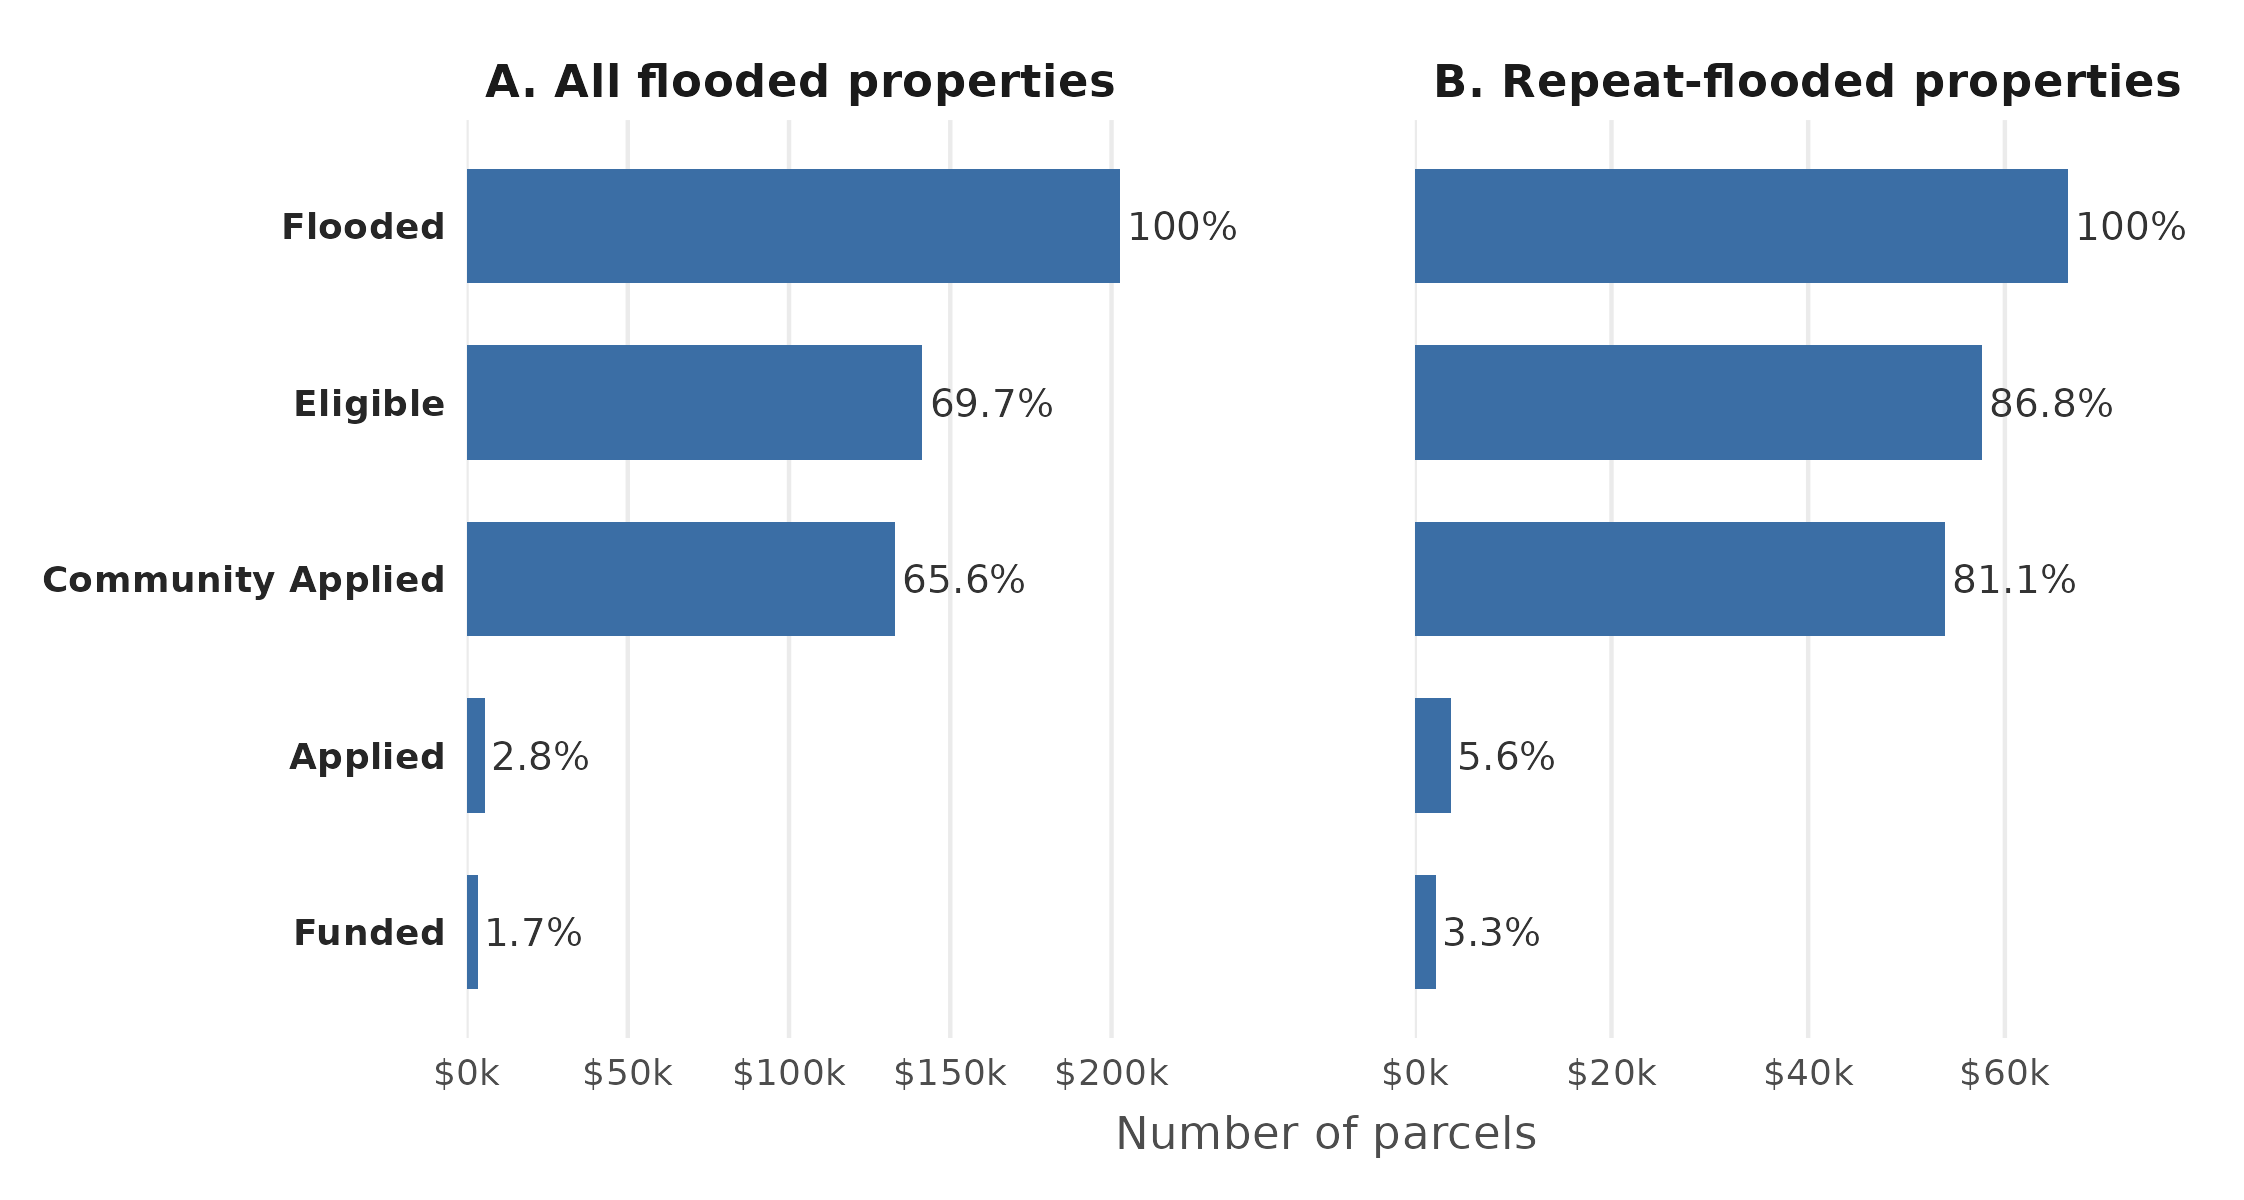{#fig-funnel fig-alt="Diagram showing parcel counts by the five pipeline stages — flooded, eligible, in an applying community, applied, funded" width="100%"}

**Fig. 2. Flooded-to-funded pipeline for residential properties in eastern North Carolina, 1996–2020.** Bars show the number of 1–4 family residential parcels at each of five sequential pipeline stages: flooded in any of the 78 modeled events; eligible (flooded during a presidentially-declared event covering the parcel’s county); in an applying community (jurisdiction with at least one HMA application during the study period); itself named on an HMA application; and ultimately funded. Panel A: all flood-exposed parcels (n = 202,623). Panel B: parcels exposed to flooding in more than one event (n = 66,443).

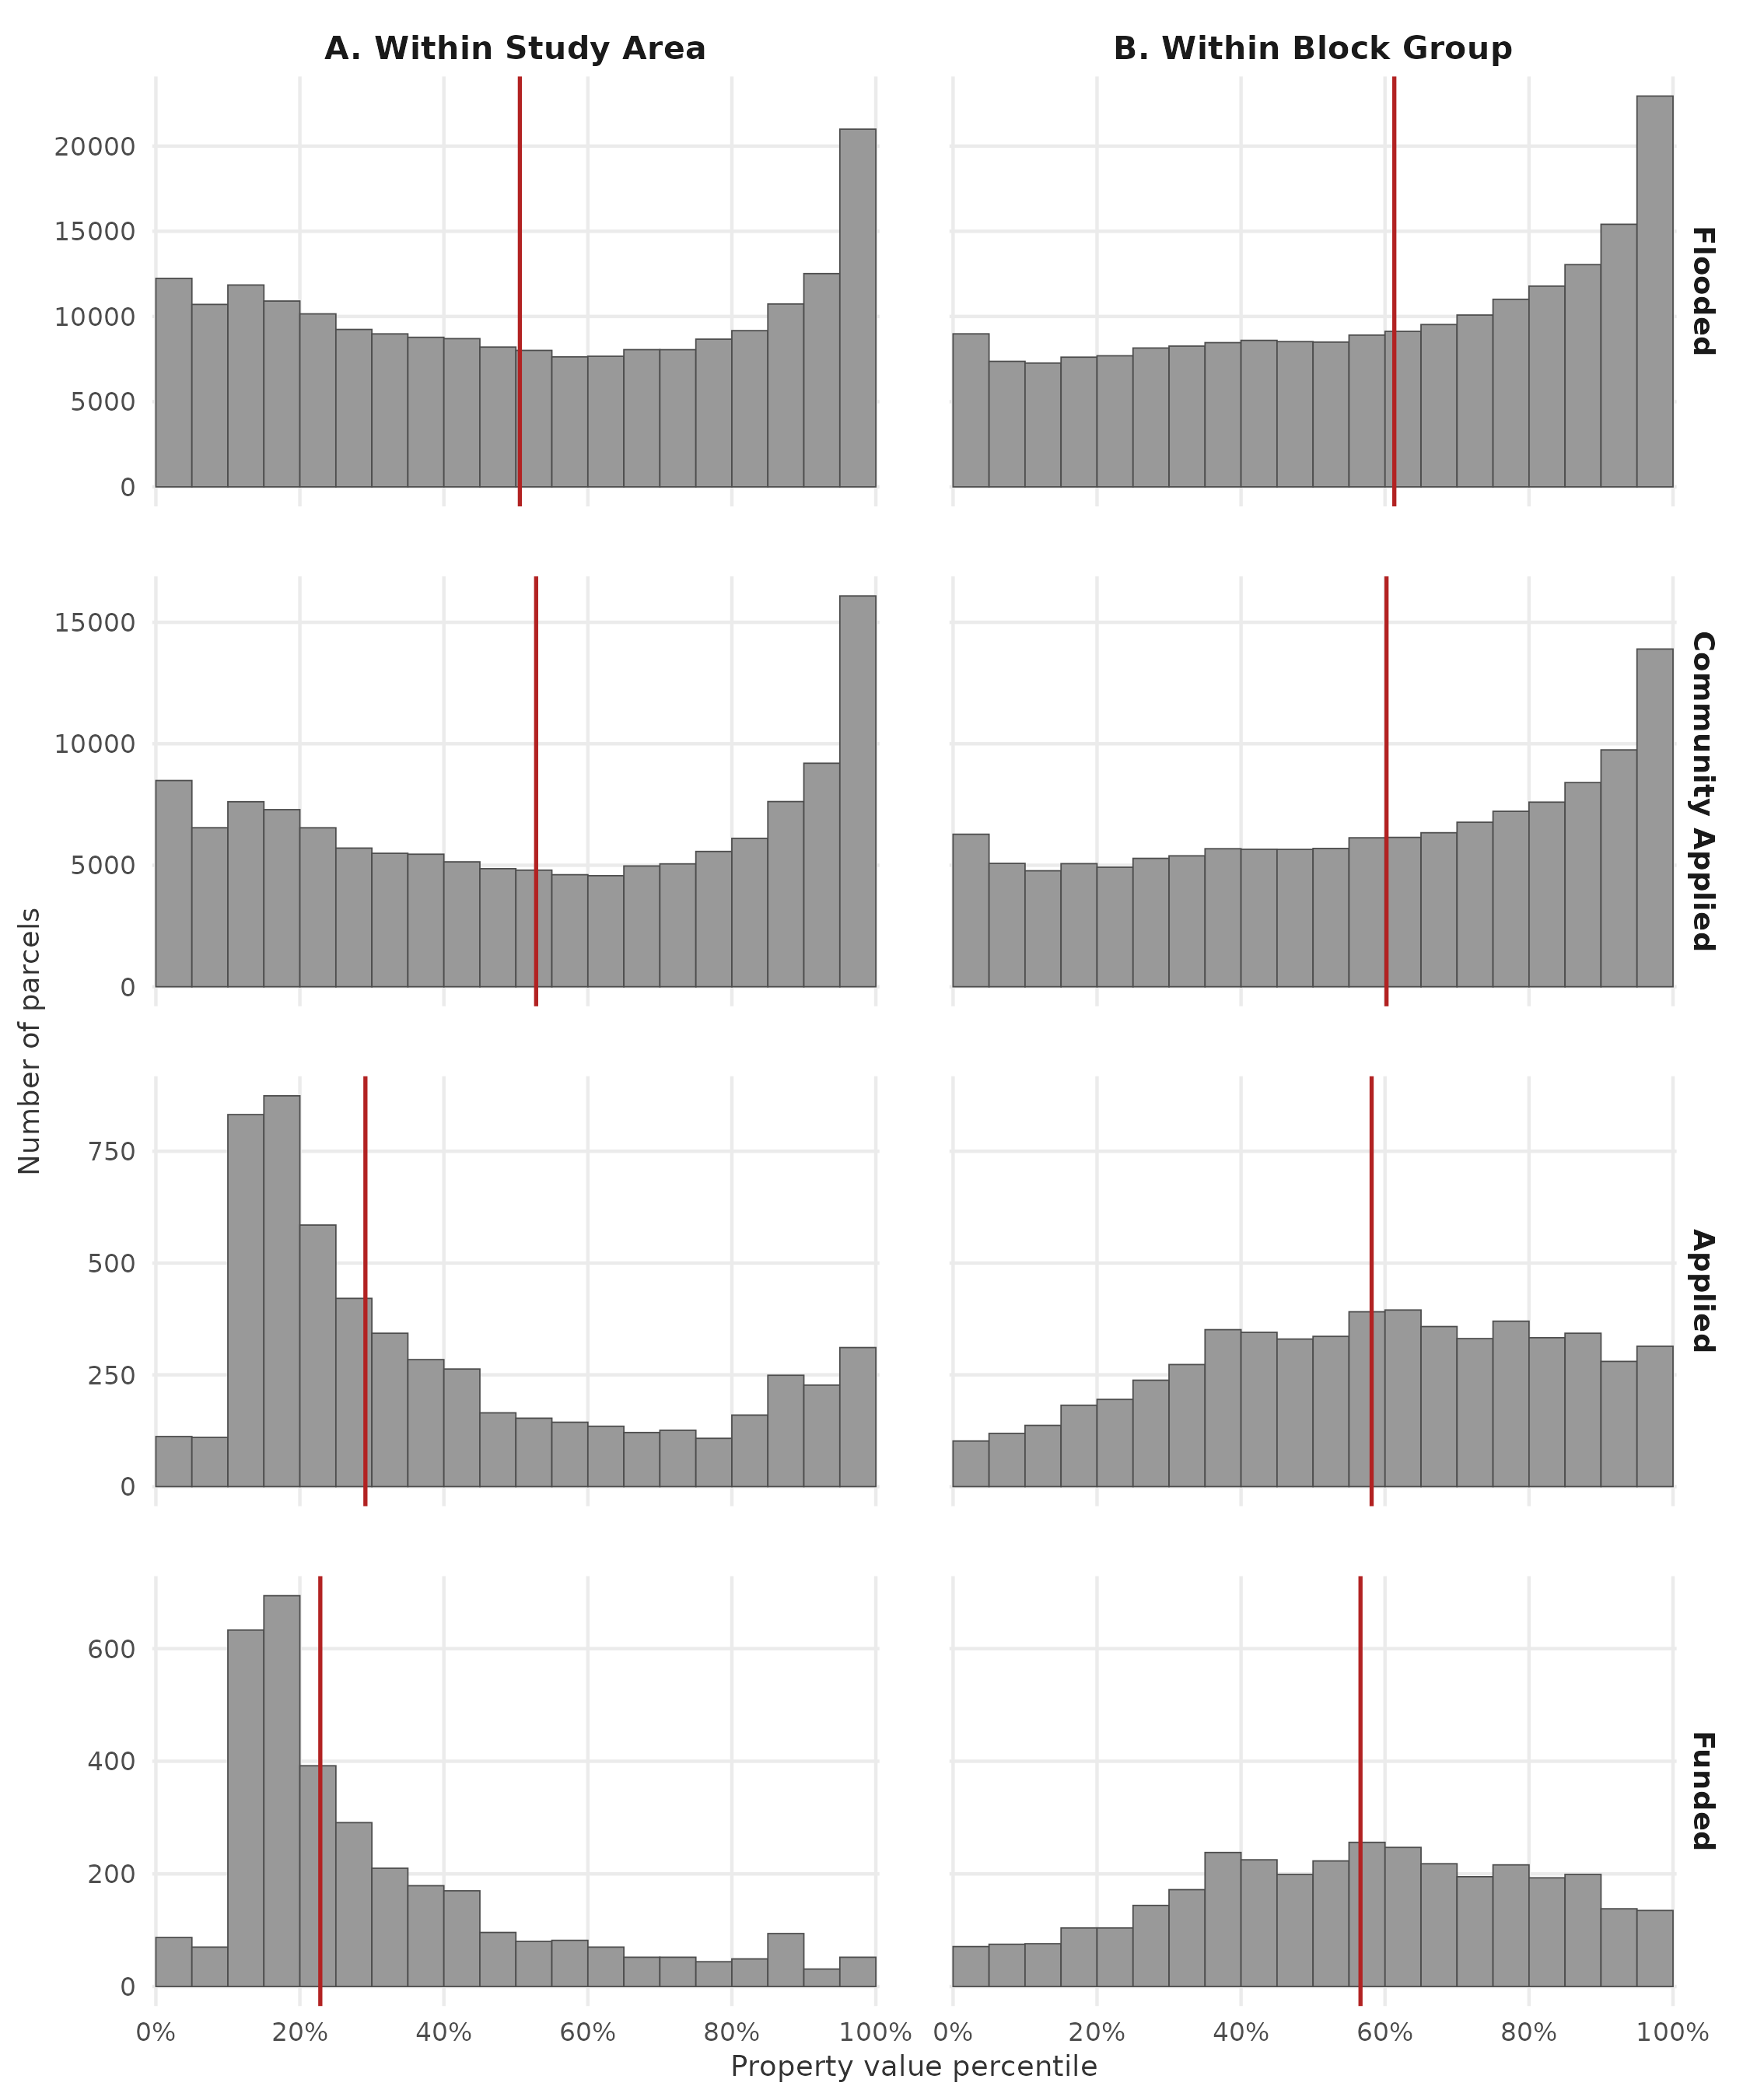{#fig-value fig-alt="Faceted histogram with two columns and four rows. Columns compare property value percentile rankings against the full study-area sample (left) versus within each parcel's own census block group (right). Rows correspond to four pipeline stages: Flooded, Community Applied, Applied, and Funded, top to bottom. Red vertical lines mark stage medians. Funded properties cluster at lower percentiles in the study-area panel but remain near the median in the block-group panel." width="100%"}

**Fig. 3. Changes in distribution of property value by HMA stage.** (A) Distribution expressed as percentile ranks relative to the entire study-area sample. (B) Distribution expressed as percentiles within each property’s block group. Property values are from CoreLogic (2022 dollars); red vertical lines mark stage medians.

The number of properties surviving each pipeline stage drops substantially, and the property-value composition shifts as well (@fig-value). Properties that flooded or that sit in communities with at least one HMA application have median values near the th–th percentile of the study-area sample (Panel A). Properties that apply for funding themselves drop to the th percentile, and those that are funded are even more affordable at the th percentile. Panel B re-ranks each property against the other parcels in its own block group: early-stage properties sit near the th–th percentile of their immediate neighborhood, while applying and funded properties land at the th and th percentiles respectively. Whether compared to the broader study area or within their own block groups, applying and funded properties are more affordable than flooded properties — but Panel B indicates they are relatively typical for their own neighborhoods rather than the cheapest houses on the block. Mitigation funding flows toward lower-value neighborhoods rather than toward the lowest-value homes within them.

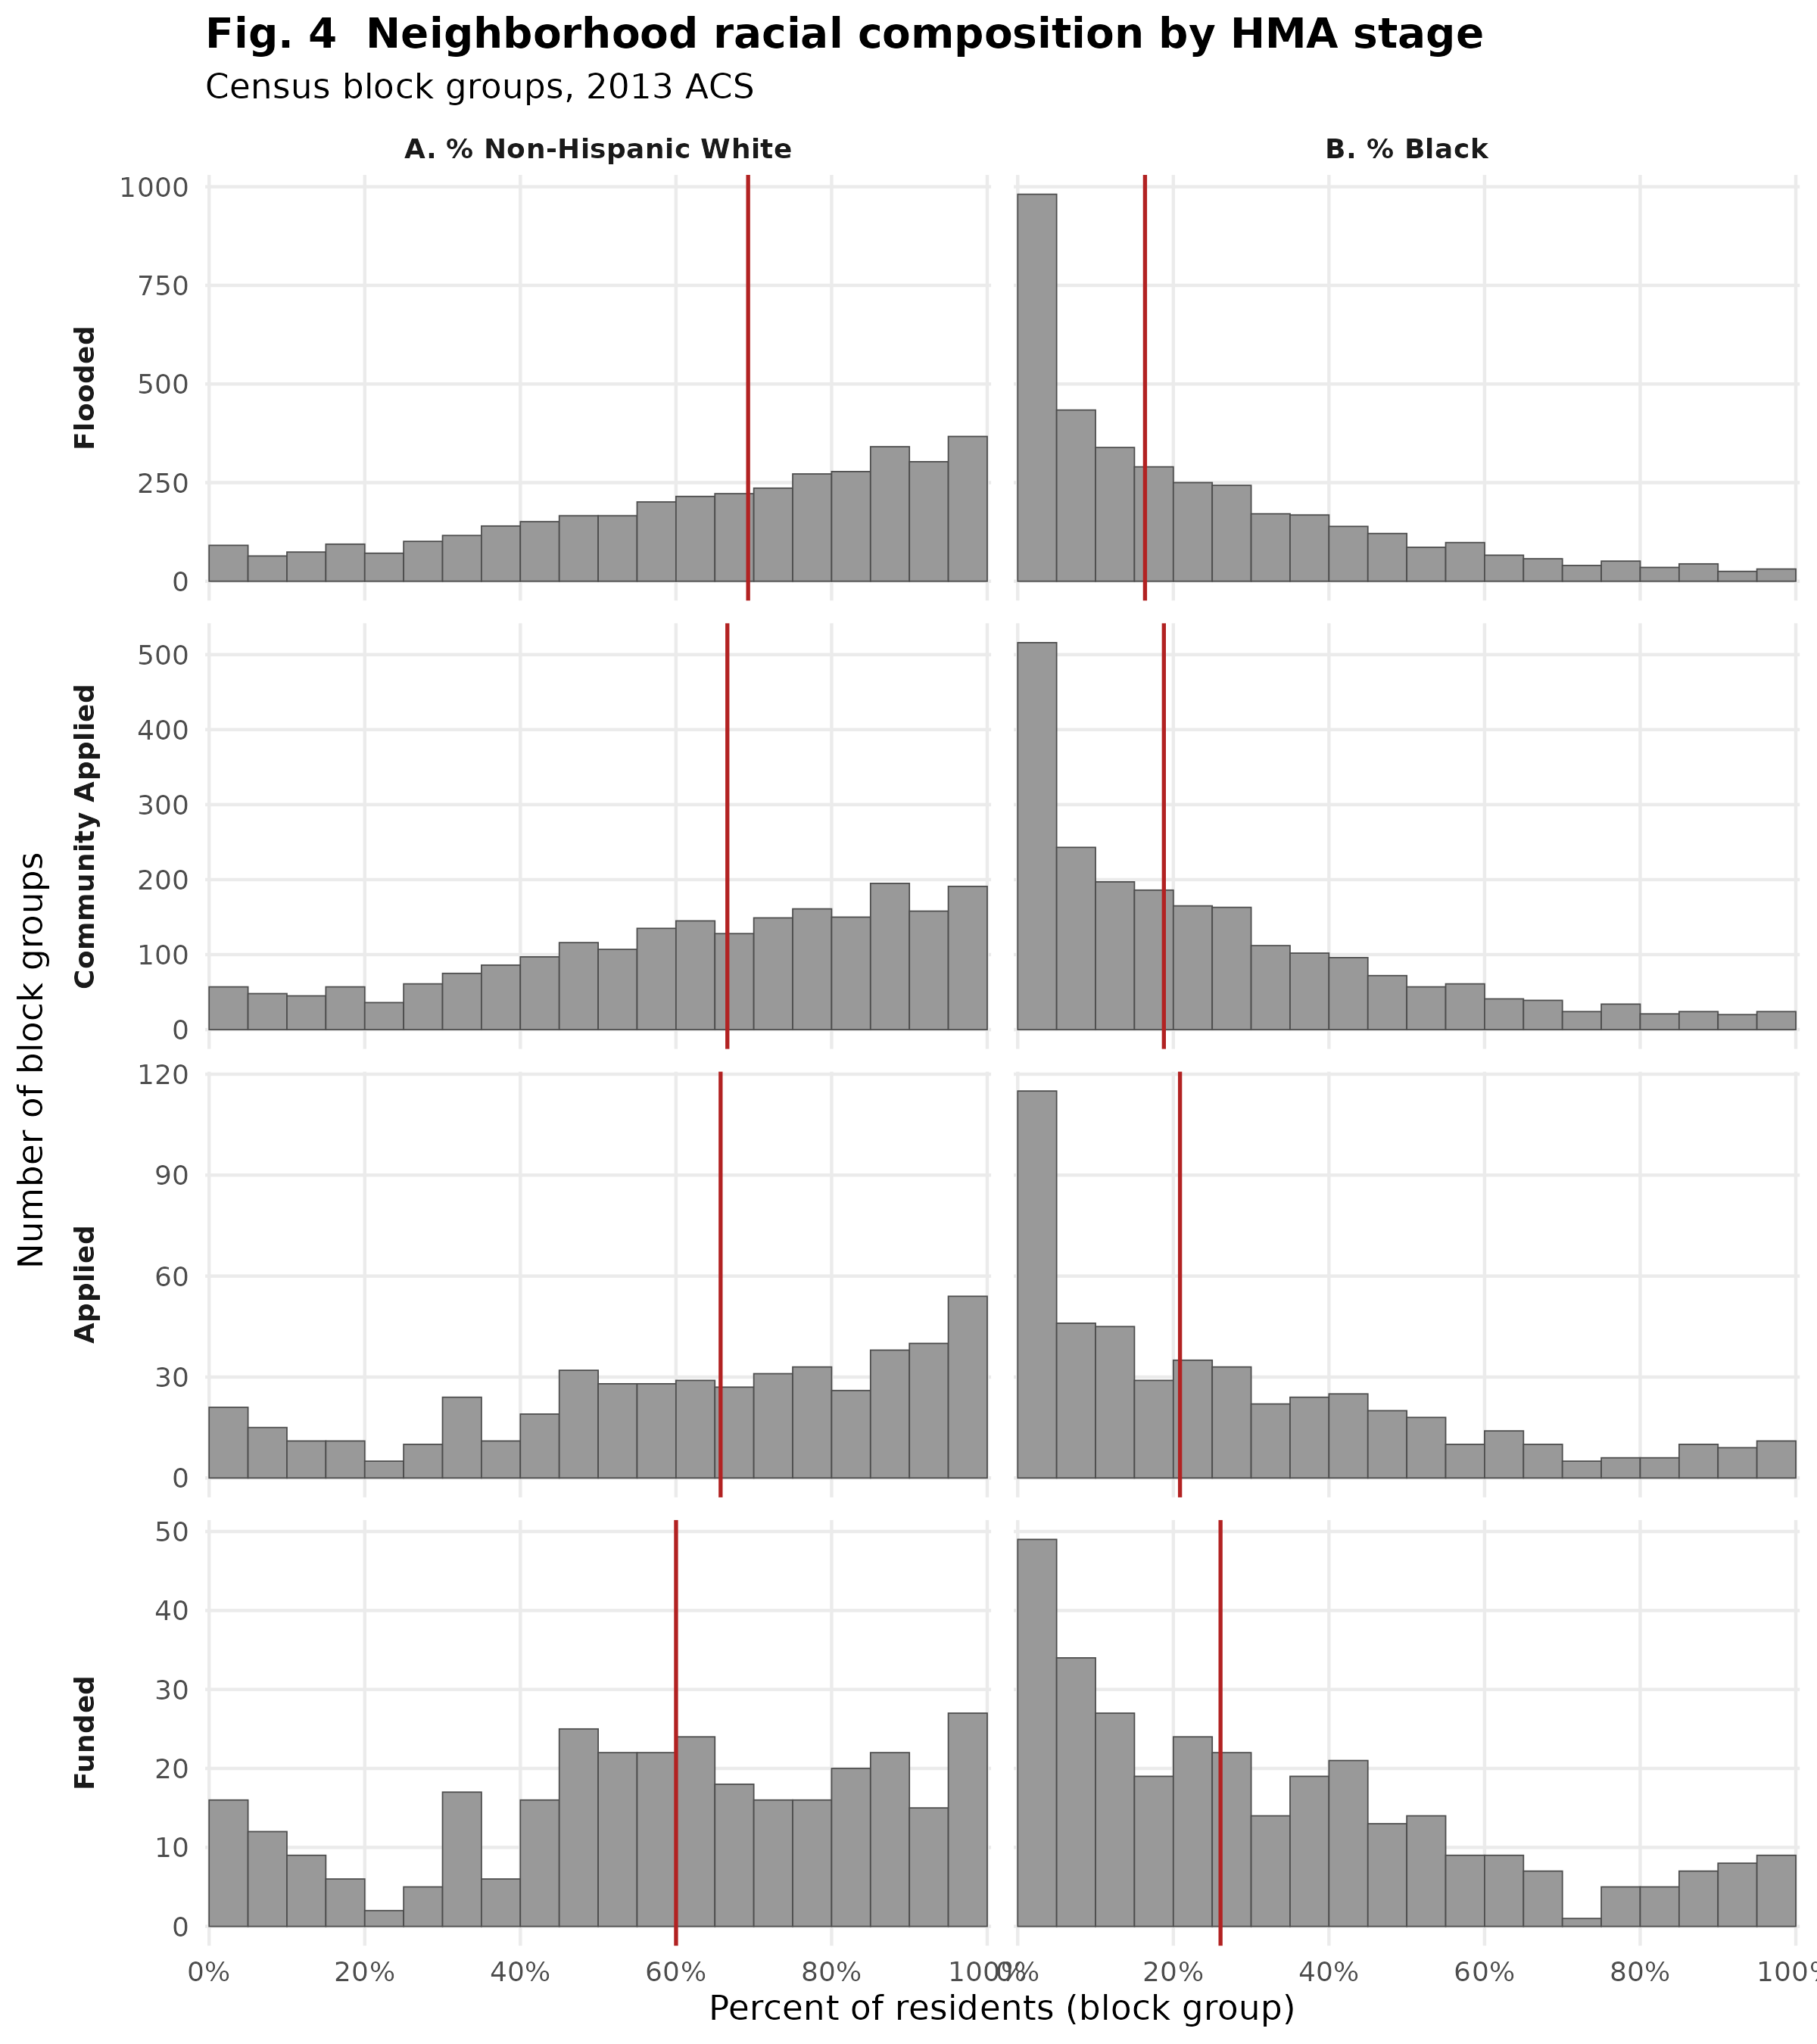{#fig-race fig-alt="Faceted histogram with two columns and four rows. Columns show the distribution of block-group percentages of non-Hispanic White residents (left) and Black residents (right). Rows correspond to four pipeline stages: Flooded, Community Applied, Applied, and Funded. Red vertical lines mark stage medians. The white-resident median shifts downward across stages while the Black-resident median shifts upward." width="100%"}

**Fig. 4. Block-group racial composition by HMA stage.** (A) Percentage of non-Hispanic White residents. (B) Percentage of Black residents. One observation per block group containing ≥ 1 residential parcel reaching the stage; demographic data from the 2013 ACS 5-year estimates. Red vertical lines mark stage medians.

Properties applying for and receiving mitigation funding are located in block groups with lower shares of non-Hispanic White residents and correspondingly higher shares of Black residents than block groups at preceding pipeline stages (@fig-race). Median NH White share declines from 69.3% at the flooded stage to 66.6% at applying communities, 65.7% at applied properties, and 60% at funded properties. Median Black share rises by a nearly equal magnitude — from 16.4% to 26.1% across the same trajectory.

# Materials and Methods

We construct a novel, multi-layered property-level dataset that links flood exposure, federal flood mitigation applications, and funding outcomes for eastern North Carolina between 1996 and 2020. The dataset combines parcel geometries from the North Carolina OneMap database, attribute records from the CoreLogic property database, address-level National Flood Insurance Program (NFIP) records used to reconstruct flood inundation footprints \[@garciaReconstructingRepetitiveFlood2025\], application and funding records from the North Carolina Department of Public Safety (NCDPS), and block-group demographic data from the American Community Survey (ACS). We use this dataset to track residential properties through five sequential stages of the flood mitigation funding pipeline (@fig-overview): whether a property has flooded, whether it is eligible for federal mitigation funding, whether its local government has applied for funding, whether the property itself is named on an application, and whether that application was funded. The framework allows us to identify, at each transition, which properties drop out and how the composition of the remaining pool shifts in terms of flood-exposure history, property value, and neighborhood racial composition.

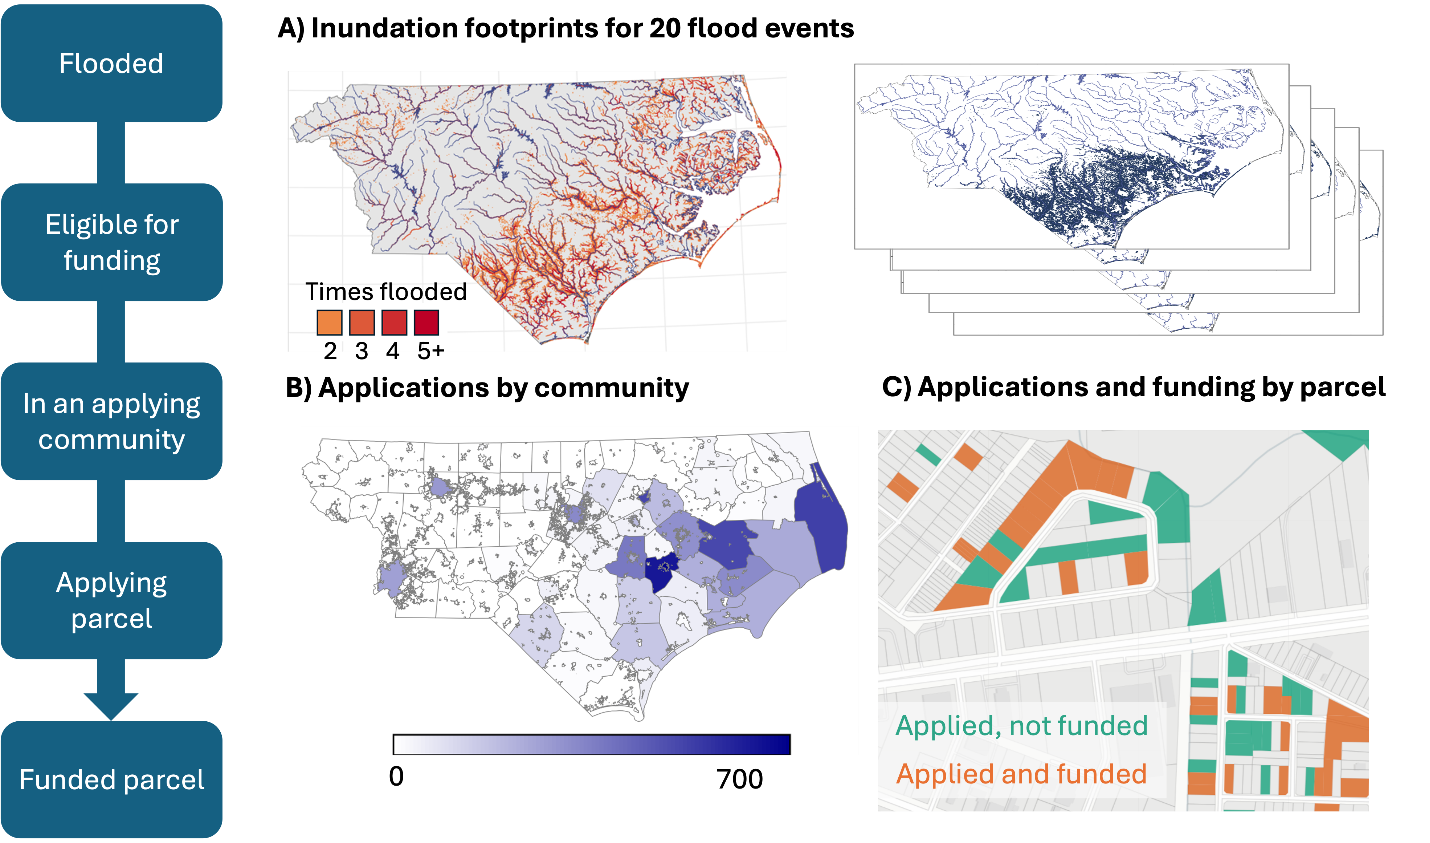{#fig-overview fig-alt="Diagram showing five pipeline stages — flooded, eligible, in an applying community, applied, funded — with the data source linked to each stage" width="100%"}

## Study area and unit of analysis

Our analysis covers the eastern portion of North Carolina, defined hydrologically as the entirety of the Neuse–Pamlico and Cape Fear watersheds together with the portions of the Pee Dee and Chowan–Roanoke watersheds that drain through the state. This domain spans 78 of North Carolina’s 100 counties and contains the bulk of the state’s repetitive flood activity over the study period.

The base unit of analysis is the residential parcel. Parcel geometries are sourced from the North Carolina OneMap database, which aggregates county tax assessor records into a statewide spatial layer. Each parcel is linked to property-level attributes (land use code, structure characteristics, assessor value) drawn from the CoreLogic property database. Where parcel records and CoreLogic records share a common identifier we match directly; the remaining parcels are matched spatially, with address-string similarity used to break ties when more than one CoreLogic record is closest. We retain 1–4 family residential parcels and exclude commercial, industrial, agricultural, and most government-owned land uses. The final analytic sample comprises **3,137,520 unique 1–4 family residential properties** across the 78-county study area.

A small number of residential parcels are recorded in CoreLogic as currently vacant or government-owned. Because completed buyouts demolish the structure and transfer the parcel to public ownership, these post-buyout parcels appear in the present-day data with property values that reflect their post-mitigation rather than pre-mitigation state. To recover a pre-mitigation value for parcels that we have reason to believe were previously residential, we impute the property value as the mean assessor value of the five nearest non-vacant residential parcels. Parcels that are vacant for reasons unrelated to mitigation are excluded from the property-value analysis.

## Flood exposure

Flood exposure is constructed at the parcel level using inundation footprints generated by the random-forest model of Garcia et al. \[-@garciaReconstructingRepetitiveFlood2025\]. The model is trained on address-level NFIP policies-in-force and claims records for January 1996 through September 2020, obtained from FEMA Region IV, and produces 30 m × 30 m gridded inundation footprints for individual flood events. We retain the 78 events with the largest claim counts in the study area, which together account for the majority of NFIP-recorded losses over the period. A parcel is classified as flooded if its geometry intersects the footprint of at least one of these 78 events; we additionally record the count of intersecting events per parcel, which we use as a continuous measure of cumulative flood-exposure intensity. This property-resolved flood history is, to our knowledge, the first parcel-scale, multi-event reconstruction of repetitive flooding in the region, and serves as the reference set against which subsequent pipeline stages are measured.

## Eligibility for federal mitigation funding

Application and funding records cover three FEMA Hazard Mitigation Assistance (HMA) programs administered by NCDPS: the Hazard Mitigation Grant Program (HMGP), the Repetitive Flood Claims Program (RFC), and the Severe Repetitive Loss Grant Program (SRL). HMGP, the largest of the three, becomes available only after a presidential disaster declaration (PDD), which is issued event-by-event and county-by-county. We therefore define a parcel as eligible for federal mitigation funding if it was inundated during an event for which the parcel’s county received a PDD. Of the 78 events in our flood-exposure dataset, 18 triggered PDDs covering at least one county in the study area; these constitute the universe of disaster declarations for North Carolina over the study period. RFC and SRL eligibility, by contrast, depend on a parcel’s NFIP claim history rather than on a PDD, and we discuss any sensitivity of our results to this distinction in the Supplementary Materials.

## Applications and funding

NCDPS provided address-level records of every project that has been submitted for HMA funding from the state’s three covered programs over the study period, together with the subset of those projects that were ultimately funded. The records identify the local sub-applicant (county or municipality) and the addresses associated with each project.

The HMA application process is administered through local governments. Households cannot apply directly to FEMA: instead, a county or municipal government compiles project documentation — including the cost-benefit analysis, NFIP claim records, and deed and title records — and submits applications on behalf of interested homeowners, often with state-level coordination from NCDPS. Local governments differ substantially in their willingness and capacity to do this work \[@machManagedRetreatVoluntary2019; @junodEquitableInvestmentsResilience2021a\]. To capture this community-level filter, we attribute every parcel to its containing municipality (or, where no municipality exists, to its containing county) and classify each jurisdiction as having applied for HMA funding at least once during the study period or not. Within applying jurisdictions, we then geocode application and funding records back to OneMap parcels and classify each property as never applied, applied but not funded, or applied and funded.

## Property values and neighborhood demographics

Property values are taken from the most recent CoreLogic vintage and used at the parcel level. To make values comparable across counties with different assessment cycles and price levels, we additionally express each property’s value as a percentile of the assessor-value distribution within its own county, and use this percentile rank as our primary property-value measure throughout the analysis.

Neighborhood-level race and income are joined at the census block-group scale. We use the 2013 vintage of the American Community Survey because it falls near the midpoint of our event window (1996–2020) and matches the demographic context that prevailed during the bulk of the analyzed disaster declarations. Block-group variables include the share of residents identifying as non-Hispanic white, the share identifying as non-Hispanic Black, and median household income. We aggregate parcel-level results to the block group when reporting demographic-composition shifts across pipeline stages.

## Pipeline analysis

The five-stage pipeline (flooded → eligible → in an applying community → applied → funded) is a sequence of nested subsets: each stage is, by construction, a subset of the previous one. We characterize each stage in three ways. First, we count the number of parcels that survive into the stage and report stage-to-stage attrition rates, separately for once-flooded and repeatedly flooded parcels. Second, we describe the distribution of flood-exposure intensity (count of intersecting events) at each stage, to test whether the parcels surviving deeper into the pipeline are systematically those with more severe flood histories. Third, we describe the distribution of property values (county-percentile rank) and block-group demographics at each stage, to identify where in the pipeline shifts in wealth and racial composition emerge.

This cross-sectional design intentionally treats the pipeline as a series of selection filters rather than estimating causal effects of any single program rule. By observing applications, funding, and flood exposure at the parcel level for every residential property in the study area, we identify the transitions at which inequities emerge, rather than inferring them from funded properties alone.

# References